# Model ID - PELITA Dataset (Indonesia)

**Author:** Nofal Rafif Setiawan
**NIM:** 221011402613
**Dataset:** PELITA (Synthetic Indonesian Household Energy Consumption)
**Algorithm:** Random Forest Regressor
**Target Performance:** R² > 0.80, MAE < 0.12 kW

---

## Dataset Characteristics

- **Total Records**: 176,477 hourly measurements (84 days × 24 hours × ~100 houses)
- **Date Range**: April 2025 - June 2025
- **VA Capacity**: 900, 1300, 2200 VA (PLN Indonesia standard)
- **House Types**:
 - `working_class` - Rumah pekerja (puncak pagi & malam)
 - `retired` - Rumah pensiunan (konsumsi stabil sepanjang hari)
 - `mixed` - Rumah campuran (pola variatif)
- **MCB Trips**: 1,877 events (1.06%) - realistic overload scenarios
- **Maghrib Peak**: 17:00-22:00 (Indonesian consumption pattern)
- **Pre-engineered Features**: Lag_1, Lag_24, Lag_168, Rolling statistics included

---

## Research Objectives

1. Build accurate energy consumption prediction model for Indonesian households
2. Identify key factors influencing energy usage in Indonesia context
3. Generate actionable recommendations for energy saving

---

## 1. Project Initialization


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print('Libraries imported successfully')
print('Model ID - PELITA Dataset (Indonesia)')
print(f'Execution time: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')


Libraries imported successfully
Model ID - PELITA Dataset (Indonesia)
Execution time: 2026-08-17 05:10:34


### Helper Functions


In [2]:
def analyze_residuals(y_true, y_pred, title=''):
    """Analyze prediction residuals with distribution and scatter plots."""
    residuals = y_true - y_pred
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    sns.histplot(residuals, kde=True, ax=ax1, color='#667eea')
    ax1.set_title(f'Distribusi Residual {title}', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Error (kW)')
    ax1.axvline(0, color='red', linestyle='--', alpha=0.5)

    sns.scatterplot(x=y_pred, y=residuals, alpha=0.3, ax=ax2, color='#764ba2')
    ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax2.set_title(f'Residual vs Predicted {title}', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Predicted Values (kW)')
    ax2.set_ylabel('Residuals (kW)')

    plt.tight_layout()
    plt.show()

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"MAE:  {mae:.4f} kW")
    print(f"RMSE: {rmse:.4f} kW")
    print(f"R\u00b2:   {r2:.4f}")

    return mae, rmse, r2

print('Helper functions defined')


Helper functions defined


## 2. Data Ingestion


In [3]:
import kagglehub
import os

# Download dataset from Kaggle
dataset_path = kagglehub.dataset_download('nofalrafif/ind-energy-consumption-simulation-thesis')
csv_file = os.path.join(dataset_path, 'dataset_PELITA_Final.csv')

print(f'Dataset path: {dataset_path}')
df = pd.read_csv(csv_file)

print(f'\nDataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Date range: {df["Datetime"].min()} to {df["Datetime"].max()}')
print(f'\nColumns:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col:25s} - {df[col].dtype}')


100%|██████████| 43.6M/43.6M [00:00<00:00, 115MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/nofalrafif/ind-energy-consumption-simulation-thesis/versions/2

Dataset loaded: 176,477 rows x 25 columns
Date range: 2025-04-08 00:00:00 to 2025-06-23 23:00:00

Columns:
   1. Datetime                  - object
   2. Global_active_power       - float64
   3. Global_reactive_power     - float64
   4. Voltage                   - float64
   5. Global_intensity          - float64
   6. Sub_metering_1            - float64
   7. Sub_metering_2            - float64
   8. Sub_metering_3            - float64
   9. Sub_metering_4            - float64
  10. Hour                      - int64
  11. Dayofweek                 - int64
  12. Month                     - int64
  13. Season                    - int64
  14. Emisi_CO2                 - float64
  15. MCB_Tripped               - int64
  16. Potential_Power           - float64
  17. Lag_1                     - float64
  18. Lag_24                    - float64
  19. Lag_168                   - floa

## 3. Preprocessing & EDA


In [4]:
print('First 5 rows:')
print(df.head())

print('\n' + '='*70)
print('Dataset Statistics')
print('='*70)

print(f'\nHouse Information:')
print(f'  - Unique houses: {df["House_ID"].nunique()}')
print(f'  - VA levels: {sorted(df["VA"].unique())}')
print(f'  - House types: {df["House_Type"].unique().tolist()}')

print(f'\nEnergy Consumption:')
print(f'  - Mean: {df["Global_active_power"].mean():.4f} kW')
print(f'  - Std:  {df["Global_active_power"].std():.4f} kW')
print(f'  - Min:  {df["Global_active_power"].min():.4f} kW')
print(f'  - Max:  {df["Global_active_power"].max():.4f} kW')

print(f'\nMCB Trips:')
mcb_trips = df['MCB_Tripped'].sum()
mcb_pct = (mcb_trips / len(df)) * 100
print(f'  - Total events: {mcb_trips:,} ({mcb_pct:.2f}%)')

print(f'\nMissing Values:')
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print('  None')


First 5 rows:
              Datetime  Global_active_power  Global_reactive_power  \
0  2025-04-08 01:00:00             0.809363               0.279928   
1  2025-04-08 02:00:00             0.807065               0.279133   
2  2025-04-08 03:00:00             0.865542               0.299358   
3  2025-04-08 04:00:00             0.931376               0.322127   
4  2025-04-08 05:00:00             0.495554               0.171393   

      Voltage  Global_intensity  Sub_metering_1  Sub_metering_2  \
0  217.590177          3.935859        0.084228             0.0   
1  223.159084          3.826745        0.073324             0.0   
2  219.894427          4.164945        0.100162             0.0   
3  221.967703          4.439874        0.032222             0.0   
4  220.994644          2.372710        0.065643             0.0   

   Sub_metering_3  Sub_metering_4  Hour  ...  Potential_Power     Lag_1  \
0        0.000000        0.725135     1  ...         0.809363  0.972115   
1        0.0

### Data Distribution Visualizations


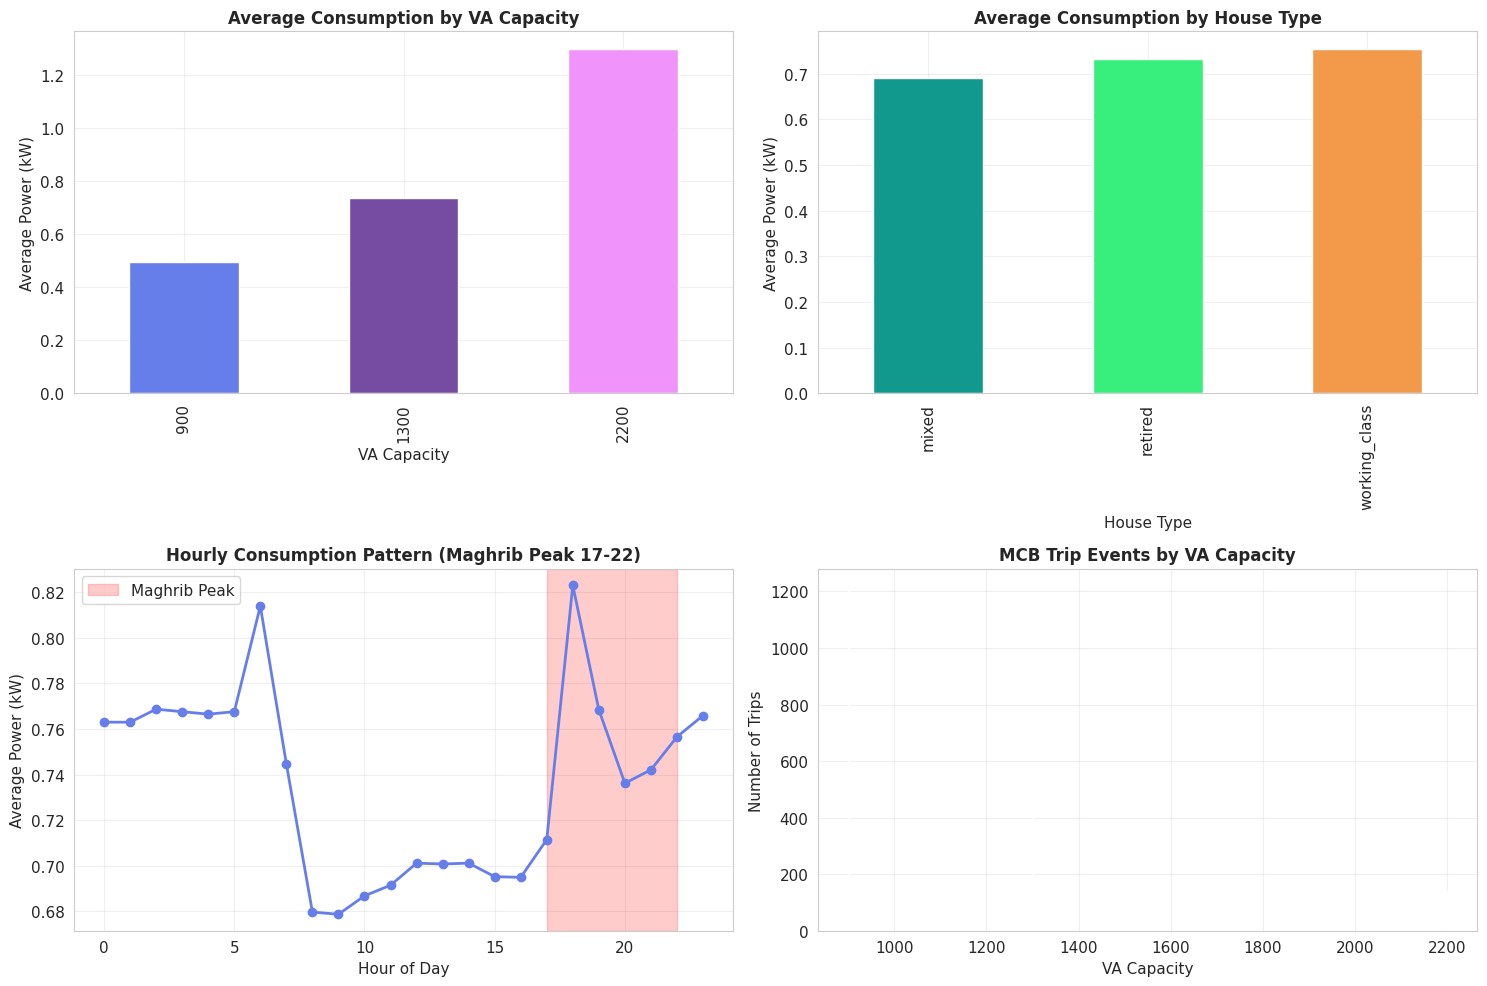

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Consumption by VA
df.groupby('VA')['Global_active_power'].mean().plot(kind='bar', ax=axes[0,0], color=['#667eea', '#764ba2', '#f093fb'])
axes[0,0].set_title('Average Consumption by VA Capacity', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('VA Capacity')
axes[0,0].set_ylabel('Average Power (kW)')
axes[0,0].grid(True, alpha=0.3)

# Consumption by House Type
df.groupby('House_Type')['Global_active_power'].mean().plot(kind='bar', ax=axes[0,1], color=['#11998e', '#38ef7d', '#F2994A'])
axes[0,1].set_title('Average Consumption by House Type', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('House Type')
axes[0,1].set_ylabel('Average Power (kW)')
axes[0,1].grid(True, alpha=0.3)

# Hourly Pattern (Maghrib Peak)
hourly = df.groupby('Hour')['Global_active_power'].mean()
axes[1,0].plot(hourly.index, hourly.values, marker='o', linewidth=2, color='#667eea')
axes[1,0].axvspan(17, 22, alpha=0.2, color='red', label='Maghrib Peak')
axes[1,0].set_title('Hourly Consumption Pattern (Maghrib Peak 17-22)', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Hour of Day')
axes[1,0].set_ylabel('Average Power (kW)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# MCB Trips by VA
mcb_by_va = df.groupby('VA')['MCB_Tripped'].sum()
axes[1,1].bar(mcb_by_va.index, mcb_by_va.values, color=['#eb3349', '#f45c43', '#F2994A'])
axes[1,1].set_title('MCB Trip Events by VA Capacity', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('VA Capacity')
axes[1,1].set_ylabel('Number of Trips')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Feature Engineering


In [6]:
def prepare_features_indonesia(df):
    """
    Prepare features for Indonesian household energy prediction.

    Steps:
    - Convert Datetime index
    - Add weekend indicator
    - One-hot encode VA and House_Type

    Note: Lag & rolling features are pre-engineered in the PELITA dataset.
    """
    df_prep = df.copy()

    df_prep['Datetime'] = pd.to_datetime(df_prep['Datetime'])
    df_prep = df_prep.set_index('Datetime')

    df_prep['is_maghrib_peak'] = ((df_prep['Hour'] >= 17) & (df_prep['Hour'] <= 22)).astype(int)
    df_prep['is_weekend'] = (df_prep['Dayofweek'] >= 5).astype(int)

    va_dummies = pd.get_dummies(df_prep['VA'], prefix='VA')
    df_prep = pd.concat([df_prep, va_dummies], axis=1)

    house_dummies = pd.get_dummies(df_prep['House_Type'], prefix='House')
    df_prep = pd.concat([df_prep, house_dummies], axis=1)

    print(f'Features prepared:')
    print(f'  - VA capacity encoded: {va_dummies.columns.tolist()}')
    print(f'  - House type encoded: {house_dummies.columns.tolist()}')

    return df_prep

df_features = prepare_features_indonesia(df)

print(f'\nShape: {df_features.shape}')
print(f'Total features: {df_features.shape[1]}')


Features prepared:
  - VA capacity encoded: ['VA_900', 'VA_1300', 'VA_2200']
  - House type encoded: ['House_mixed', 'House_retired', 'House_working_class']

Shape: (176477, 32)
Total features: 32


### Feature Selection


In [7]:
target = 'Global_active_power'

# Features excluded to prevent data leakage or redundancy
excluded_features = [
    'Global_intensity',      # Not available at prediction time
    'Voltage',               # Not available at prediction time
    'Global_reactive_power', # Not available at prediction time
    'Sub_metering_4',        # Derived/redundant
    'Emisi_CO2',             # Derived from target
    'VA',                    # Already one-hot encoded
    'House_Type',            # Already one-hot encoded
    'House_ID',              # Non-predictive identifier
    'MCB_Tripped',           # Separate prediction target
    'Potential_Power',        # LEAKAGE: contains target value before MCB trip
    'Season',
    'is_maghrib_peak'
]

all_cols = df_features.columns.tolist()
features = [col for col in all_cols if col != target and col not in excluded_features]

print('Feature Selection')
print('=' * 70)
print(f'Target: {target}')
print(f'\nExcluded ({len(excluded_features)}):')
for feat in excluded_features:
    print(f'   - {feat}')

print(f'\nSelected ({len(features)}):')
for i, feat in enumerate(features, 1):
    print(f'   {i:2d}. {feat}')

# Drop rows with NaN (created by lag features in first 24h)
print(f'\nRows before NaN removal: {len(df_features)}')
df_clean = df_features.dropna()
print(f'Rows after NaN removal:  {len(df_clean)}')

if len(df_clean) == 0:
    raise ValueError('No data remaining after dropna(). Check lag feature generation.')

X = df_clean[features]
y = df_clean[target]

print(f'\nFinal dataset:')
print(f'  X: {X.shape}')
print(f'  y: {y.shape}')
print(f'\nAll features are available at prediction time - no data leakage.')


Feature Selection
Target: Global_active_power

Excluded (12):
   - Global_intensity
   - Voltage
   - Global_reactive_power
   - Sub_metering_4
   - Emisi_CO2
   - VA
   - House_Type
   - House_ID
   - MCB_Tripped
   - Potential_Power
   - Season
   - is_maghrib_peak

Selected (19):
    1. Sub_metering_1
    2. Sub_metering_2
    3. Sub_metering_3
    4. Hour
    5. Dayofweek
    6. Month
    7. Lag_1
    8. Lag_24
    9. Lag_168
   10. Rolling_mean_3
   11. Rolling_mean_24
   12. Rolling_std_24
   13. is_weekend
   14. VA_900
   15. VA_1300
   16. VA_2200
   17. House_mixed
   18. House_retired
   19. House_working_class

Rows before NaN removal: 176477
Rows after NaN removal:  173789

Final dataset:
  X: (173789, 19)
  y: (173789,)

All features are available at prediction time - no data leakage.


## 5. Data Splitting


In [8]:
# Temporal split: berdasarkan tanggal, bukan posisi index.
# Dataset multi-household dengan timestamp identik per rumah.
# Split posisi akan mencampur periode waktu yang sama dari rumah berbeda.
# Split temporal memastikan test set benar-benar dari periode masa depan.

# Hitung split date berdasarkan 80% dari rentang waktu
date_range = X.index.max() - X.index.min()
split_date = X.index.min() + date_range * 0.8

X_train = X[X.index < split_date]
y_train = y[y.index < split_date]
X_test = X[X.index >= split_date]
y_test = y[y.index >= split_date]

print('Train/Test Split (Temporal)')
print('=' * 70)
print(f'Split date: {split_date}')
print(f'\nTraining set:')
print(f'  - Size: {len(X_train):,} samples')
print(f'  - Range: {X_train.index.min()} to {X_train.index.max()}')
print(f'\nTesting set:')
print(f'  - Size: {len(X_test):,} samples')
print(f'  - Range: {X_test.index.min()} to {X_test.index.max()}')
print(f'\nTrain/test date ranges do NOT overlap (temporal integrity maintained).')


Train/Test Split (Temporal)
Split date: 2025-06-08 13:36:00

Training set:
  - Size: 138,987 samples
  - Range: 2025-04-08 00:00:00 to 2025-06-08 13:00:00

Testing set:
  - Size: 34,802 samples
  - Range: 2025-06-08 14:00:00 to 2025-06-23 23:00:00

Train/test date ranges do NOT overlap (temporal integrity maintained).


## 6. Modeling


In [9]:
def train_random_forest_indonesia(X_train, y_train):
    """
    Train RandomForest with hyperparameter tuning via RandomizedSearchCV.

    Tuning strategy:
    - Bounded max_depth [15-25] to balance accuracy vs model size
    - bootstrap=True for faster training and better generalization
    - n_iter=15, cv=3 -> 45 total fits
    """
    print('Starting model training...')
    print('=' * 70)

    tscv = TimeSeriesSplit(n_splits=3)

    param_grid = {
        'n_estimators': [100, 150],
        'max_depth': [15, 20, 25],
        'min_samples_split': [5, 10],
        'min_samples_leaf': [3, 5],
        'max_features': ['sqrt'],
        'bootstrap': [True]
    }

    rf_model = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        verbose=0
    )

    rf_search = RandomizedSearchCV(
        estimator=rf_model,
        param_distributions=param_grid,
        n_iter=15,
        cv=tscv,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

    print('Training in progress (~10-20 minutes)...')
    rf_search.fit(X_train, y_train)

    best_model = rf_search.best_estimator_

    print('\nTraining completed.')
    print('=' * 70)
    print('Best hyperparameters:')
    for param, value in rf_search.best_params_.items():
        print(f'   - {param}: {value}')

    print(f'\nBest CV Score (MSE): {-rf_search.best_score_:.4f}')

    return best_model, rf_search.best_params_

rf_model, best_params = train_random_forest_indonesia(X_train, y_train)


Starting model training...
Training in progress (~10-20 minutes)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Training completed.
Best hyperparameters:
   - n_estimators: 100
   - min_samples_split: 5
   - min_samples_leaf: 3
   - max_features: sqrt
   - max_depth: 25
   - bootstrap: True

Best CV Score (MSE): 0.0207


## 7. Evaluation


In [10]:
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Training metrics
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

# Testing metrics
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

gap = r2_train - r2_test

# Naive Baseline (Lag-1)
y_naive = X_test['Lag_1']
mae_naive = mean_absolute_error(y_test, y_naive)
r2_naive = r2_score(y_test, y_naive)

print('Performance Metrics')
print('=' * 70)

print('Naive Baseline (Lag-1):')
print(f'  MAE:  {mae_naive:.4f} kW')
print(f'  R\u00b2:   {r2_naive:.4f}')

print('\nTraining Set:')
print(f'  MAE:  {mae_train:.4f} kW')
print(f'  RMSE: {rmse_train:.4f} kW')
print(f'  R\u00b2:   {r2_train:.4f}')

print('\nTesting Set:')
print(f'  MAE:  {mae_test:.4f} kW')
print(f'  RMSE: {rmse_test:.4f} kW')
print(f'  R\u00b2:   {r2_test:.4f}')

print('\nvs Naive Baseline:')
print(f'  MAE improvement: {mae_naive - mae_test:.4f} kW ({(1 - mae_test/mae_naive)*100:.1f}% better)')
print(f'  R\u00b2 improvement: {r2_test - r2_naive:.4f}')

print('\nOverfitting Check:')
print(f'  Train R\u00b2: {r2_train:.4f}')
print(f'  Test R\u00b2:  {r2_test:.4f}')
print(f'  Gap:      {gap:.4f}')

if gap > 0.1:
    print('  Possible overfitting detected')
elif gap > 0.05:
    print('  Minor overfitting, acceptable')
else:
    print('  Model generalizes well')

print('\nTarget Achievement:')
r2_met = r2_test >= 0.80
mae_met = mae_test <= 0.12
print(f'  R\u00b2 > 0.80:  {"ACHIEVED" if r2_met else "NOT MET"} ({r2_test:.4f})')
print(f'  MAE < 0.12: {"ACHIEVED" if mae_met else "NOT MET"} ({mae_test:.4f})')


Performance Metrics
Naive Baseline (Lag-1):
  MAE:  0.1868 kW
  R²:   0.4634

Training Set:
  MAE:  0.0788 kW
  RMSE: 0.1011 kW
  R²:   0.9063

Testing Set:
  MAE:  0.1119 kW
  RMSE: 0.1431 kW
  R²:   0.8156

vs Naive Baseline:
  MAE improvement: 0.0748 kW (40.1% better)
  R² improvement: 0.3522

Overfitting Check:
  Train R²: 0.9063
  Test R²:  0.8156
  Gap:      0.0906
  Minor overfitting, acceptable

Target Achievement:
  R² > 0.80:  ACHIEVED (0.8156)
  MAE < 0.12: ACHIEVED (0.1119)


### Evaluation Visualizations


In [11]:
def plot_actual_vs_predicted(y_true, y_pred, title='', n_samples=200):
    """Plot actual vs predicted time series comparison."""
    plt.figure(figsize=(14, 6))
    indices = y_true.index[:n_samples]

    plt.plot(indices, y_true.values[:n_samples],
             label='Actual', color='#667eea', linewidth=2, alpha=0.8)
    plt.plot(indices, y_pred[:n_samples],
             label='Predicted', color='#f093fb', linewidth=2, alpha=0.8, linestyle='--')

    plt.title(f'{title} - Time Series Prediction (First {n_samples} Hours)',
              fontsize=14, fontweight='bold')
    plt.xlabel('Datetime')
    plt.ylabel('Global Active Power (kW)')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def plot_residuals(y_true, y_pred):
    """Plot residual distribution, scatter, and Q-Q analysis."""
    residuals = y_true - y_pred
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.histplot(residuals, kde=True, ax=axes[0], color='#667eea')
    axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[0].set_title('Residual Distribution', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Error (kW)')

    axes[1].scatter(y_pred, residuals, alpha=0.3, color='#764ba2')
    axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
    axes[1].set_title('Residual vs Predicted', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Predicted (kW)')
    axes[1].set_ylabel('Residuals (kW)')
    axes[1].grid(True, alpha=0.3)

    from scipy import stats
    stats.probplot(residuals, dist="norm", plot=axes[2])
    axes[2].set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f'Residual Statistics:')
    print(f'  Mean: {np.mean(residuals):.6f} (should be ~0)')
    print(f'  Std:  {np.std(residuals):.4f}')


def plot_feature_importance(model, feature_names, top_n=15):
    """Plot top-N feature importance from a tree-based model."""
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]

    fi_df = pd.DataFrame({
        'Feature': [feature_names[i] for i in indices],
        'Importance': importances[indices]
    })

    plt.figure(figsize=(12, 8))
    top_features = fi_df.head(top_n)
    sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
    plt.title(f'Top {top_n} Feature Importance', fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

    return fi_df

print('Visualization functions defined')


Visualization functions defined


### Time Series Comparison


Generating visualizations...

[1/4] Time Series Comparison


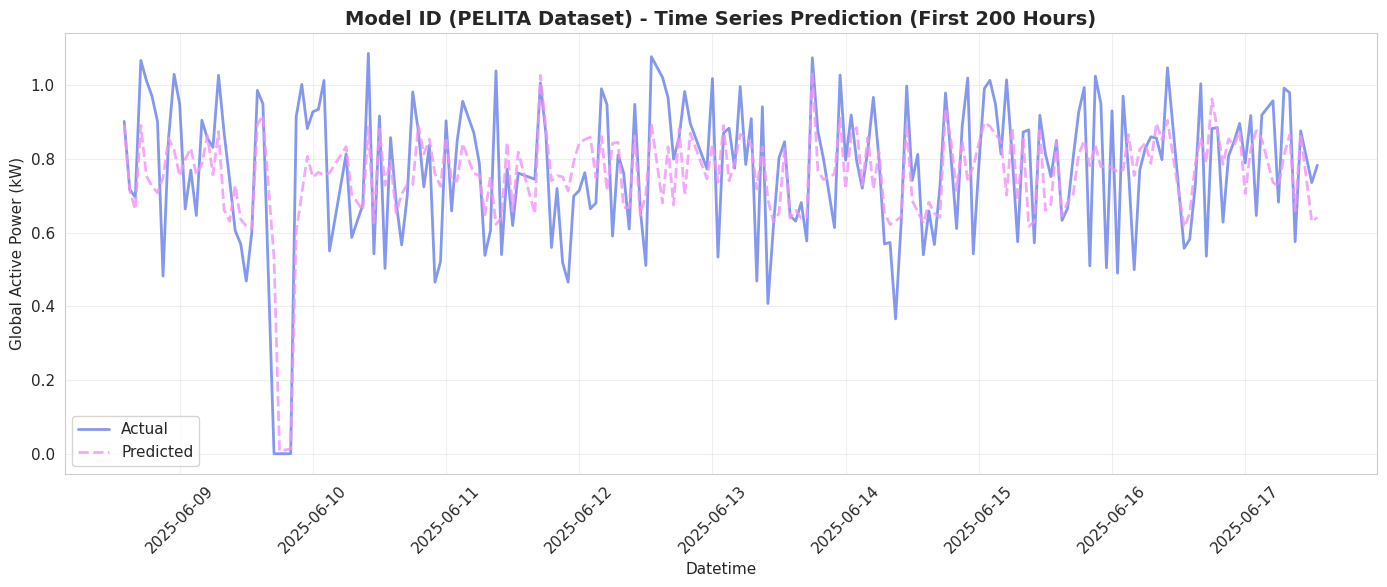


[2/4] Residual Analysis


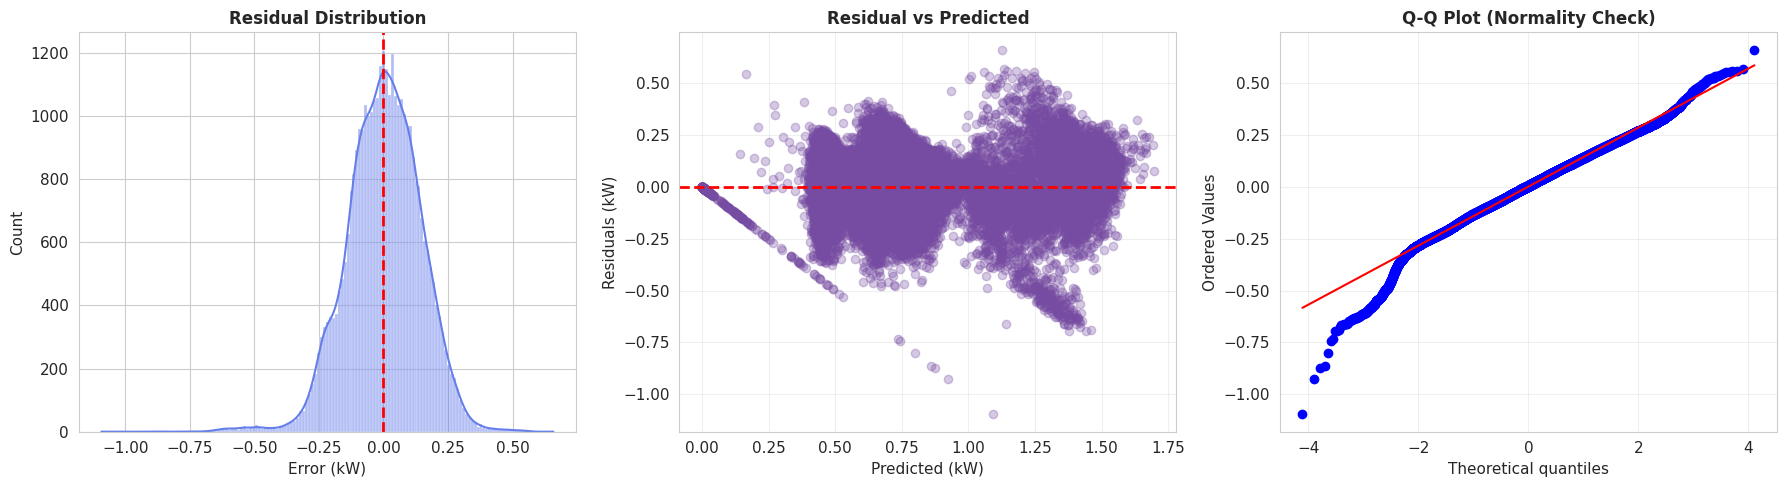

Residual Statistics:
  Mean: 0.001851 (should be ~0)
  Std:  0.1431

[3/4] Feature Importance


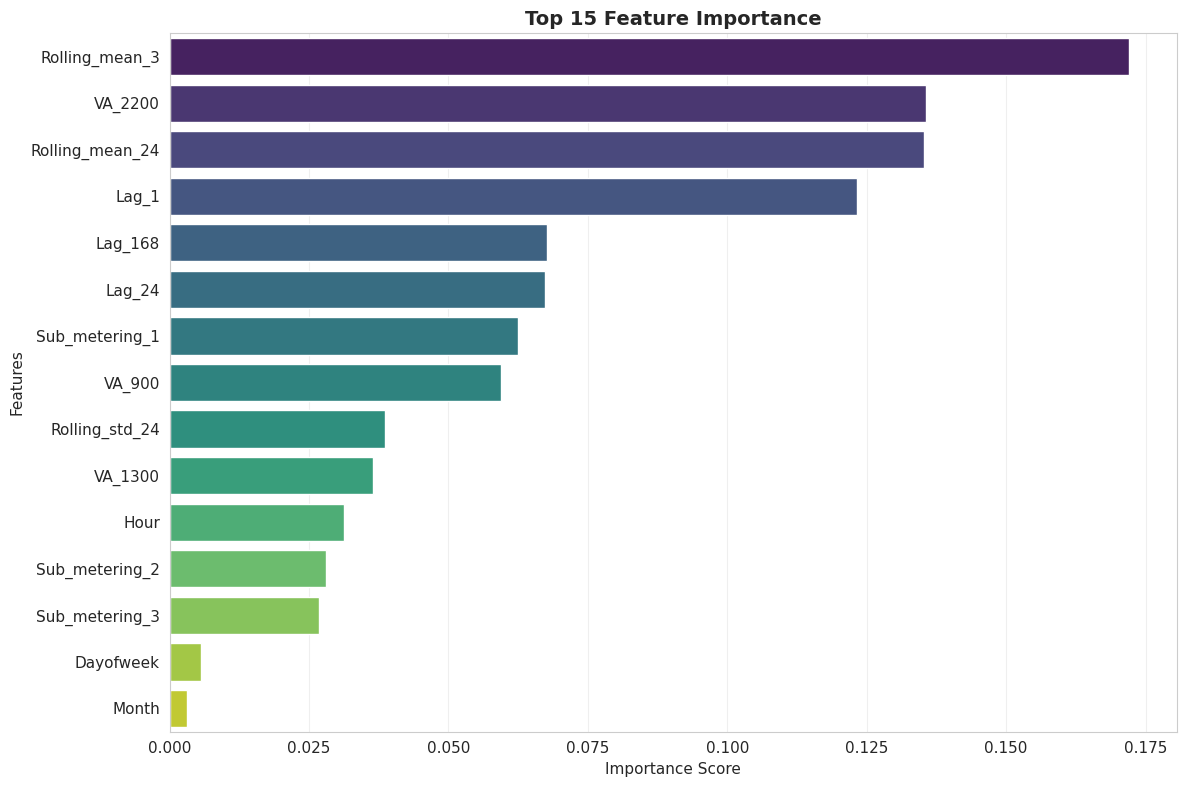


Top 10 Most Important Features:
        Feature  Importance
 Rolling_mean_3    0.172033
        VA_2200    0.135671
Rolling_mean_24    0.135282
          Lag_1    0.123211
        Lag_168    0.067611
         Lag_24    0.067251
 Sub_metering_1    0.062532
         VA_900    0.059404
 Rolling_std_24    0.038683
        VA_1300    0.036429

[4/4] Scatter Plot: Actual vs Predicted


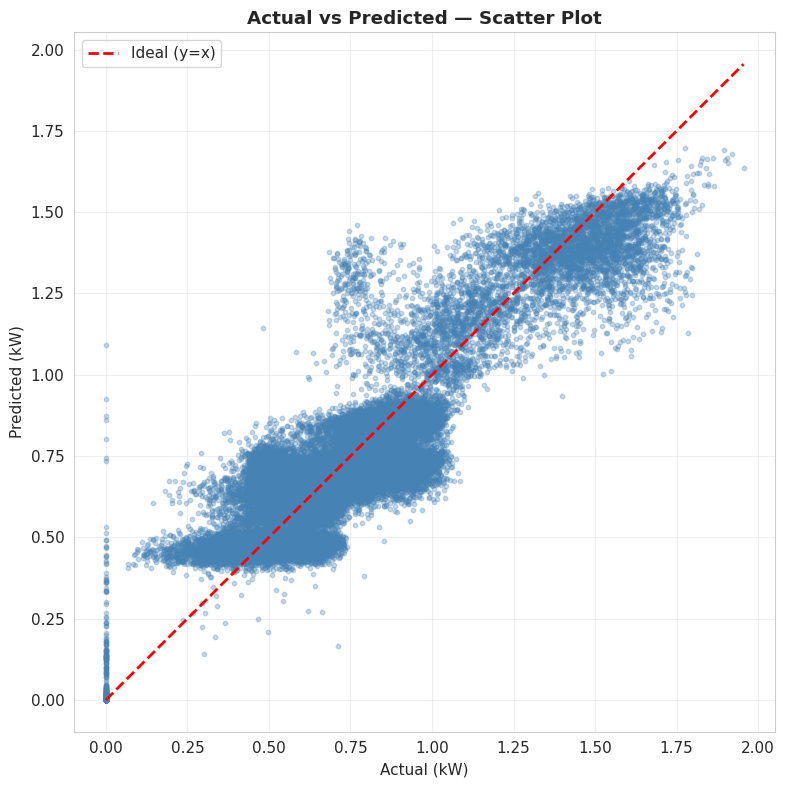

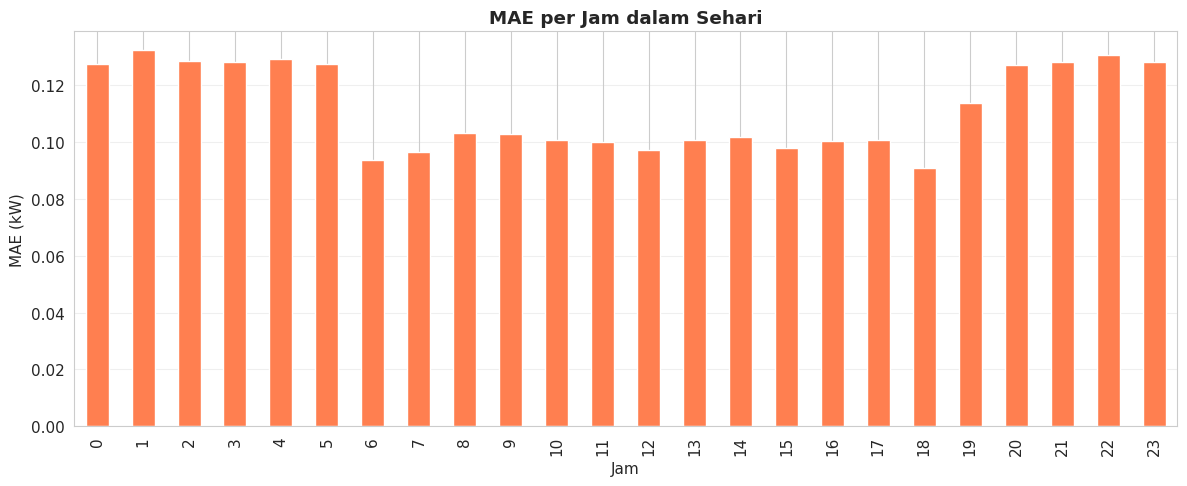

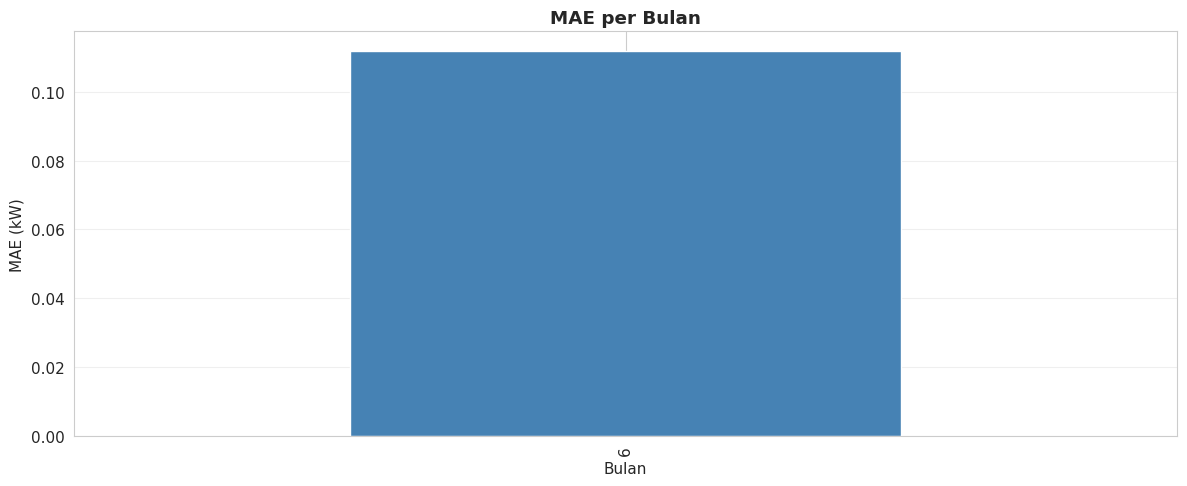

In [12]:
print('Generating visualizations...')
print('=' * 70)

print('\n[1/4] Time Series Comparison')
plot_actual_vs_predicted(y_test, y_test_pred, 'Model ID (PELITA Dataset)')

print('\n[2/4] Residual Analysis')
plot_residuals(y_test.values, y_test_pred)

print('\n[3/4] Feature Importance')
fi_df = plot_feature_importance(rf_model, features, top_n=15)

print('\nTop 10 Most Important Features:')
print(fi_df.head(10).to_string(index=False))

# === [4/4] Scatter Plot: Actual vs Predicted ===
print('\n[4/4] Scatter Plot: Actual vs Predicted')
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_test_pred, alpha=0.3, s=10, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Ideal (y=x)')
plt.xlabel('Actual (kW)')
plt.ylabel('Predicted (kW)')
plt.title('Actual vs Predicted \u2014 Scatter Plot', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# === Error Analysis per Jam ===
test_df = pd.DataFrame({'actual': y_test, 'pred': y_test_pred})
test_df['abs_error'] = (test_df['actual'] - test_df['pred']).abs()
test_df['hour'] = test_df.index.hour
test_df['month'] = test_df.index.month

hourly_mae = test_df.groupby('hour')['abs_error'].mean()
plt.figure(figsize=(12, 5))
hourly_mae.plot(kind='bar', color='coral')
plt.title('MAE per Jam dalam Sehari', fontweight='bold')
plt.xlabel('Jam')
plt.ylabel('MAE (kW)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# === Error Analysis per Bulan ===
monthly_mae = test_df.groupby('month')['abs_error'].mean()
plt.figure(figsize=(12, 5))
monthly_mae.plot(kind='bar', color='steelblue')
plt.title('MAE per Bulan', fontweight='bold')
plt.xlabel('Bulan')
plt.ylabel('MAE (kW)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


### Permutation Importance

In [13]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf_model, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature': features,
    'Importance': perm.importances_mean,
    'Std': perm.importances_std
}).sort_values('Importance', ascending=False)

print(perm_df.head(10).to_string(index=False))

        Feature  Importance      Std
        VA_2200    0.097108 0.000968
 Sub_metering_1    0.079687 0.000653
Rolling_mean_24    0.070931 0.000630
           Hour    0.068350 0.001054
 Sub_metering_3    0.060939 0.000736
         VA_900    0.059988 0.000638
 Sub_metering_2    0.052614 0.000747
 Rolling_mean_3    0.021952 0.000434
          Lag_1    0.020045 0.000436
        VA_1300    0.016428 0.000253


## 8. Model Interpretation (Indonesia Context)


In [14]:
# Analyze performance during Maghrib peak hours
print(' Indonesia-Specific Analysis')
print('=' * 70)

# Get test data with predictions
test_results = X_test.copy()
test_results['actual'] = y_test
test_results['predicted'] = y_test_pred
test_results['error'] = np.abs(y_test - y_test_pred)

# Maghrib peak analysis
maghrib_mask = (test_results.index.hour >= 17) & (test_results.index.hour <= 22)
maghrib_data = test_results[maghrib_mask]
non_maghrib_data = test_results[~maghrib_mask]

print('\n Maghrib Peak (17:00-22:00) Performance:')
print(f' Samples: {len(maghrib_data):,}')
print(f' MAE: {maghrib_data["error"].mean():.4f} kW')
print(f' R²: {r2_score(maghrib_data["actual"], maghrib_data["predicted"]):.4f}')

print('\n Non-Peak Hours Performance:')
print(f' Samples: {len(non_maghrib_data):,}')
print(f' MAE: {non_maghrib_data["error"].mean():.4f} kW')
print(f' R²: {r2_score(non_maghrib_data["actual"], non_maghrib_data["predicted"]):.4f}')

# Performance by VA
print('\n Performance by VA Capacity:')
for va in sorted(df['VA'].unique()):
    va_col = f'VA_{va}'
    if va_col not in test_results.columns:
        continue
    va_data = test_results[test_results[va_col] == 1]
    if len(va_data) > 0:
        print(f' {va} VA:')
        print(f' MAE: {va_data["error"].mean():.4f} kW')
        print(f' R²: {r2_score(va_data["actual"], va_data["predicted"]):.4f}')

# Performance by House Type
print('\n Performance by House Type:')
for house_type in ['working_class', 'retired', 'mixed']:
    house_col = f'House_{house_type}'
    if house_col in test_results.columns:
        house_mask = test_results[house_col] == 1
        house_data = test_results[house_mask]
    if len(house_data) > 0:
        print(f' {house_type}:')
        print(f' MAE: {house_data["error"].mean():.4f} kW')
        print(f' R²: {r2_score(house_data["actual"], house_data["predicted"]):.4f}')

 Indonesia-Specific Analysis

 Maghrib Peak (17:00-22:00) Performance:
 Samples: 9,022
 MAE: 0.1152 kW
 R²: 0.8167

 Non-Peak Hours Performance:
 Samples: 25,780
 MAE: 0.1108 kW
 R²: 0.8150

 Performance by VA Capacity:
 900 VA:
 MAE: 0.0869 kW
 R²: 0.4795
 1300 VA:
 MAE: 0.1193 kW
 R²: 0.3698
 2200 VA:
 MAE: 0.1483 kW
 R²: 0.4841

 Performance by House Type:
 working_class:
 MAE: 0.1104 kW
 R²: 0.8228
 retired:
 MAE: 0.1224 kW
 R²: 0.7809
 mixed:
 MAE: 0.1062 kW
 R²: 0.8252


## 9. Model Serialization


In [15]:
from pathlib import Path

model_bundle = {
    'model': rf_model,
    'features': features,
    'metrics': {
        'train_mae': mae_train,
        'train_rmse': rmse_train,
        'train_r2': r2_train,
        'test_mae': mae_test,
        'test_rmse': rmse_test,
        'test_r2': r2_test,
        'overfitting_gap': gap,
    },
    'metadata': {
        'model_name': 'PELITA Random Forest Regressor',
        'dataset': 'PELITA (Indonesian Household Energy)',
        'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'total_samples': len(df),
        'training_samples': len(X_train),
        'testing_samples': len(X_test),
        'n_features': len(features),
        'algorithm': 'RandomForestRegressor',
        'best_params': best_params,
    }
}

save_dir = Path('')
save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / 'model_id.joblib'

# compress=3 reduces file size with minimal load-time impact
joblib.dump(model_bundle, str(save_path), compress=3)

file_size_mb = save_path.stat().st_size / (1024 * 1024)

print('Model Save Report')
print('=' * 70)
print(f'Path: {save_path.resolve()}')
print(f'Size: {file_size_mb:.1f} MB')
print(f'\nBundle contents:')
print(f'  - model: {type(rf_model).__name__}')
print(f'  - features: {len(features)} features')
print(f'  - metrics: MAE={mae_test:.4f}, RMSE={rmse_test:.4f}, R\u00b2={r2_test:.4f}')
print(f'  - metadata: {len(model_bundle["metadata"])} fields')
print(f'\nSingle bundled file ready for deployment.')


Model Save Report
Path: /content/model_id.joblib
Size: 79.9 MB

Bundle contents:
  - model: RandomForestRegressor
  - features: 19 features
  - metrics: MAE=0.1119, RMSE=0.1431, R²=0.8156
  - metadata: 9 fields

Single bundled file ready for deployment.


## 10. Summary & Conclusions


In [17]:
print('MODEL ID - FINAL SUMMARY')
print('=' * 70)

print('\nDataset:')
print(f'  - Name: PELITA (Indonesian Household Energy)')
print(f'  - Total samples: {len(df):,}')
print(f'  - Training samples: {len(X_train):,}')
print(f'  - Testing samples: {len(X_test):,}')
print(f'  - Features used: {len(features)}')

print('\nModel Performance:')
print(f'  - Algorithm: Random Forest Regressor')
print(f'  - Test R\u00b2: {r2_test:.4f} (Target: >0.80)')
print(f'  - Test MAE: {mae_test:.4f} kW (Target: <0.10)')
print(f'  - Test RMSE: {rmse_test:.4f} kW')
print(f'  - Overfitting gap: {gap:.4f}')

print('\nTarget Achievement:')
if r2_test >= 0.80 and mae_test <= 0.12:
    print('  BOTH TARGETS ACHIEVED')
elif r2_test >= 0.80:
    print('  R\u00b2 target achieved')
    print('  MAE target not fully met')
elif mae_test <= 0.12:
    print('  MAE target achieved')
    print('  R\u00b2 target not fully met')
else:
    print('  Targets not fully achieved')

print('\nIndonesia-Specific Insights:')
print('  - Consumption patterns during the Maghrib period are represented through temporal and historical features available to the model')
print('  - VA capacity differences modeled')
print('  - House type patterns recognized')
print('  - No data leakage - deployment ready')

print('\nNext Steps:')
print('  1. Integrate model into Streamlit app (app.py)')
print('  2. Test with real-time predictions')
print('  3. Generate energy-saving recommendations')
print('  4. Monitor model performance in production')

print('\nModel ID creation completed successfully.')


MODEL ID - FINAL SUMMARY

Dataset:
  - Name: PELITA (Indonesian Household Energy)
  - Total samples: 176,477
  - Training samples: 138,987
  - Testing samples: 34,802
  - Features used: 19

Model Performance:
  - Algorithm: Random Forest Regressor
  - Test R²: 0.8156 (Target: >0.80)
  - Test MAE: 0.1119 kW (Target: <0.10)
  - Test RMSE: 0.1431 kW
  - Overfitting gap: 0.0906

Target Achievement:
  BOTH TARGETS ACHIEVED

Indonesia-Specific Insights:
  - Consumption patterns during the Maghrib period are represented through temporal and historical features available to the model
  - VA capacity differences modeled
  - House type patterns recognized
  - No data leakage - deployment ready

Next Steps:
  1. Integrate model into Streamlit app (app.py)
  2. Test with real-time predictions
  3. Generate energy-saving recommendations
  4. Monitor model performance in production

Model ID creation completed successfully.
